In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import urllib.request
import os
import zipfile
import pretty_midi
import json
import pickle
from collections import Counter

In [2]:
ZIP_DIR = '../data/'
RAW_DIR = '../data/raw/'
PROC_DIR = '../data/processed/'

STEPS_PER_BEAT = 16
MAX_SHIFT = STEPS_PER_BEAT * 4

os.makedirs(ZIP_DIR, exist_ok=True)
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)

In [3]:
urls = [
    'https://archive.org/download/doommusic/doommusic.zip', 
    'https://archive.org/download/doom2music/doom2music.zip', 
]

zip_paths = []

for url in urls:
    zip_path = ZIP_DIR + url.split('/')[-1]
    zip_paths.append(zip_path)
    if not os.path.exists(zip_path):
        print(f'Downloading: {url}...', end='', flush=True)
        urllib.request.urlretrieve(url, zip_path)
        print(' OK')
    else:
        print(f'File {zip_path} exists, skipping')
# adding final doom
zip_paths.append(ZIP_DIR + 'finaldoommusic.zip')

for zip_path in zip_paths:
    print(f'Unzipping {zip_path}...', end='', flush=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(RAW_DIR)
    print(' OK')

midi_files = [f for f in os.listdir(RAW_DIR) if f.endswith('.mid')]

print(f"File count: {len(midi_files)}")

File ../data/doommusic.zip exists, skipping
File ../data/doom2music.zip exists, skipping
Unzipping ../data/doommusic.zip... OK
Unzipping ../data/doom2music.zip... OK
Unzipping ../data/finaldoommusic.zip... OK
File count: 102


In [4]:
for zip_path in zip_paths:
    print(f'Unzipping {zip_path}...', end='', flush=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(RAW_DIR)
    print(' OK')

midi_files = [f for f in os.listdir(RAW_DIR) if f.endswith('.mid')]

print(f"File count: {len(midi_files)}")

midi_files = [f for f in os.listdir(RAW_DIR) if f.endswith('.mid')]


records = []
for file in midi_files:
    path = os.path.join(RAW_DIR, file)
    midi = pretty_midi.PrettyMIDI(path)

    n_instruments = len(midi.instruments)
    n_notes = sum(len(inst.notes) for inst in midi.instruments)
    duration = midi.get_end_time()
    tempos = midi.get_tempo_changes()[1]
    avg_tempo = np.mean(tempos)
    inst_names = [pretty_midi.program_to_instrument_name(inst.program) for inst in midi.instruments if not inst.is_drum]
    drum_track = any(inst.is_drum for inst in midi.instruments)

    records.append({
        'file': file,
        'duration_s': duration,
        'n_instruments': n_instruments,
        'n_notes': n_notes,
        'avg_tempo': avg_tempo,
        'has_drums': drum_track,
        'instruments': inst_names,
    })
records = pd.DataFrame(records)
display(records.head())
display(records.sort_values(by='duration_s'))

records = records[records['file'] != 'd_bunny.mid']

Unzipping ../data/doommusic.zip... OK
Unzipping ../data/doom2music.zip... OK
Unzipping ../data/finaldoommusic.zip... OK
File count: 102


,file,duration_s,n_instruments,n_notes,avg_tempo,has_drums,instruments
0,01 - Detonation - Dragonfly.mid,233.023116,11,8404,86.000052,True,"[Lead 1 (square), Lead 2 (sawtooth), Electric ..."
1,02 - Don't Stop Bleedin' - Lippeth.mid,199.929787,10,6213,68.713941,True,"[Electric Bass (pick), Lead 2 (sawtooth), Lead..."
2,03 - Triangular Currents - pcorf.mid,138.240000,15,7609,125.000000,True,"[Lead 1 (square), Lead 1 (square), Lead 8 (bas..."
3,04 - Broken Mirror - Tristan Clark.mid,208.941072,18,5977,85.000043,True,"[Pad 6 (metallic), String Ensemble 2, Ocarina,..."
4,05 - The St. Louis Slammer - Cammy.mid,226.341520,14,5032,122.999969,True,"[Agogo, String Ensemble 1, Bright Acoustic Pia..."


,file,duration_s,n_instruments,n_notes,avg_tempo,has_drums,instruments
80,d_introa.mid,6.812527,8,58,95.000143,True,"[Synth Strings 2, Synth Strings 2, Pad 7 (halo..."
79,d_intro.mid,6.812527,12,110,95.000143,True,"[Acoustic Grand Piano, Timpani, Synth Strings ..."
47,d_dm2ttl.mid,15.888799,9,184,95.000143,True,"[Synth Strings 2, Synth Strings 2, Timpani, Xy..."
9,0a - The Mothership's Wake - continuum.mid & C...,16.734375,6,176,160.000000,True,"[Tremolo Strings, Lead 2 (sawtooth), Synth Bas..."
38,d_bunny.mid,61.596596,12,742,95.000143,True,"[Pan Flute, Orchestral Harp, Piccolo, Bassoon,..."
...,...,...,...,...,...,...,...
25,23 - Return of the Troubles - Jeremy Doyle.mid,355.220000,15,8437,100.000000,True,"[Synth Bass 1, Synth Brass 1, FX 7 (echoes), F..."
99,d_the_da.mid,416.174420,9,3294,95.000143,True,"[Fretless Bass, Whistle, Synth Choir, FX 5 (br..."
97,d_theda2.mid,416.174420,9,3294,95.000143,True,"[Fretless Bass, Whistle, Synth Choir, FX 5 (br..."
98,d_theda3.mid,416.174420,9,3294,95.000143,True,"[Fretless Bass, Whistle, Synth Choir, FX 5 (br..."


In [5]:
records = records.drop_duplicates(subset=['n_notes'])
print(f'Rows left: {len(records)}')

Rows left: 80


In [6]:
records = records[records['duration_s']>=60]
print(f'Rows left: {len(records)}')

Rows left: 76


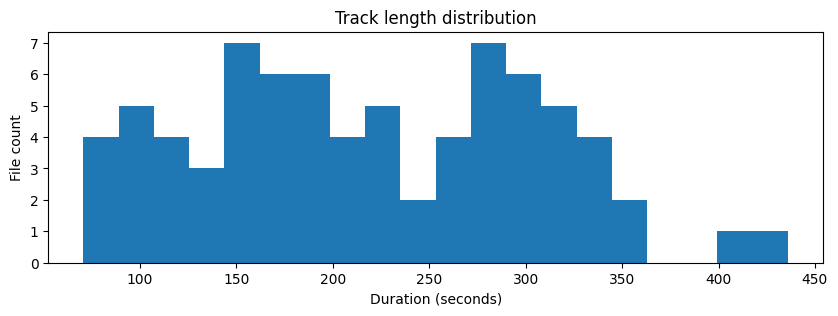

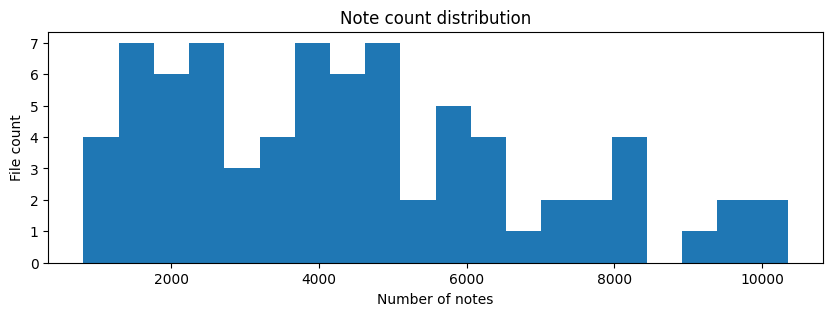

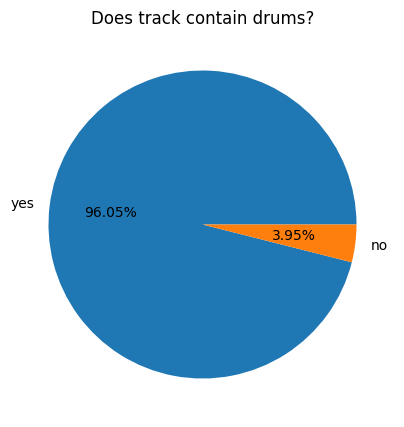

In [7]:
plt.figure(figsize=(10,3))
plt.hist(records['duration_s'], bins=20)
plt.xlabel('Duration (seconds)')
plt.ylabel('File count')
plt.title('Track length distribution')
plt.show()

plt.figure(figsize=(10,3))
plt.hist(records['n_notes'], bins=20)
plt.xlabel('Number of notes')
plt.ylabel('File count')
plt.title('Note count distribution')
plt.show()

plt.figure(figsize=(5,5))
plt.pie(records['has_drums'].value_counts(), labels=['yes', 'no'], autopct='%1.2f%%');
plt.title('Does track contain drums?');

In [8]:
def vocab():
    tokens = ['PAD', 'BOS', 'EOS']
    tokens += [f'NOTE_ON_{p}' for p in range(128)]
    tokens += [f'NOTE_OFF_{p}' for p in range(128)]
    tokens += [f'DRUM_{p}'     for p in range(128)]
    tokens += [f'PROGRAM_{p}' for p in range(128)]
    tokens += [f'SHIFT_{p}' for p in range(1, MAX_SHIFT+1)]
    token2id = {t: i for i, t in enumerate(tokens)}
    return token2id, {i: t for t, i in token2id.items()}

def midi_to_events(path):
    midi = pretty_midi.PrettyMIDI(path)
    tempos = midi.get_tempo_changes()[1]
    bpm = tempos[0]
    sec_per_step = (60.0/bpm) / STEPS_PER_BEAT
    raw = []   # (step, kind (0-off, 1-on, 2-drum), pitch, program)
    for inst in midi.instruments:
        for note in inst.notes:
            s = int(round(note.start/sec_per_step))
            e = int(round(note.end/sec_per_step))
            if e <= s:
                e = s+1
            if inst.is_drum:
                raw.append((s, 2, note.pitch, 0))
            else:
                raw.append((s, 1, note.pitch, inst.program))
                raw.append((e, 0, note.pitch, inst.program))
    raw.sort(key = lambda x: (x[0], x[1]))  # sorted by time, then kind

    events, curr = ['BOS'], 0
    for step, kind, pitch, prog in raw:
        delta = step-curr
        while delta > 0:
            s = min(delta, MAX_SHIFT)
            events.append(f'SHIFT_{s}')
            delta-=s
        curr = step
        if kind==1:
            events.append(f'PROGRAM_{prog}')    
            events.append(f'NOTE_ON_{pitch}')
        elif kind==0:
            events.append(f'NOTE_OFF_{pitch}')
        else:
            events.append(f'DRUM_{pitch}')
    events.append('EOS')
    return events

In [9]:
token2id, id2token = vocab()

sequences = {}
for name in records['file']:
    ev = midi_to_events(os.path.join(RAW_DIR, name))
    ids = [token2id[i] for i in ev]
    sequences[name] = ids

lengths = [len(s) for s in sequences.values()]
print(f'File count: {len(sequences)}')
print(f'All tokens: {sum(lengths)}')
print(f'Avarage length: {np.mean(lengths):.0f}')
print(f'Min / Max: {min(lengths)} / {max(lengths)}')

File count: 76
All tokens: 931588
Avarage length: 12258
Min / Max: 2160 / 28140


In [10]:
with open(os.path.join(PROC_DIR, 'vocab.json'), 'w') as f:
    json.dump(token2id, f)

with open(os.path.join(PROC_DIR, 'sequences.pkl'), 'wb') as f:
    pickle.dump(sequences, f)

In [11]:
def events_to_midi(events, steps_per_beat, bpm=95):
    sec_per_step = (60.0 / bpm) / steps_per_beat
    midi      = pretty_midi.PrettyMIDI()
    insts     = {}     # program -> Instrument (melodyczne)
    drum_inst = None   # jeden wspólny kanał perkusji
    active    = {}     # pitch -> [(start_step, program)]
    cur, last_prog = 0, 0

    for ev in events:
        if ev in ('BOS', 'EOS', 'PAD'):
            continue
        if ev.startswith('SHIFT_'):
            cur += int(ev.split('_')[1])
        elif ev.startswith('PROGRAM_'):
            last_prog = int(ev.split('_')[1])
        elif ev.startswith('NOTE_ON_'):
            pitch = int(ev.split('_')[-1])
            active.setdefault(pitch, []).append((cur, last_prog))
        elif ev.startswith('NOTE_OFF_'):
            pitch = int(ev.split('_')[-1])
            if active.get(pitch):
                start_step, prog = active[pitch].pop(0)
                start = start_step * sec_per_step
                end   = cur * sec_per_step
                if end > start:
                    if prog not in insts:
                        insts[prog] = pretty_midi.Instrument(program=prog)
                    insts[prog].notes.append(pretty_midi.Note(100, pitch, start, end))
        elif ev.startswith('DRUM_'):
            pitch = int(ev.split('_')[1])
            start = cur * sec_per_step
            end   = start + sec_per_step
            if drum_inst is None:
                drum_inst = pretty_midi.Instrument(program=0, is_drum=True)
            drum_inst.notes.append(pretty_midi.Note(100, pitch, start, end))

    for inst in insts.values():
        midi.instruments.append(inst)
    if drum_inst is not None:
        midi.instruments.append(drum_inst)
    return midi

In [12]:
events = midi_to_events(os.path.join(RAW_DIR, "d_e1m1.mid"))
for f in records['file']:
    events = midi_to_events(os.path.join(RAW_DIR, f))
    events_to_midi(events, STEPS_PER_BEAT).write(os.path.join(PROC_DIR, f))
    print("Zapisano", f)

Zapisano 01 - Detonation - Dragonfly.mid
Zapisano 02 - Don't Stop Bleedin' - Lippeth.mid
Zapisano 03 - Triangular Currents - pcorf.mid
Zapisano 04 - Broken Mirror - Tristan Clark.mid
Zapisano 05 - The St. Louis Slammer - Cammy.mid
Zapisano 06 - Wretched Harangue - Dragonfly & Lippeth.mid
Zapisano 07 - Escaping the Doomed Fortress - Myrgharok.mid
Zapisano 08 - Growling Belly - JD Herrera.mid
Zapisano 09 - Revenant Capoeira - wallabra & continuum.mid.mid
Zapisano 0b - TeNeT - Cammy.mid
Zapisano 0c - Technoparchment - Varis Alpha.mid
Zapisano 10 - Oakset - Cammy.mid
Zapisano 11 - Source of Stress - Doomkid & Jimmy.mid
Zapisano 12 - Inside the Devil's Lungs - JD Herrera.mid
Zapisano 13 - Hey There, Moonbeam - Cammy & Lippeth.mid
Zapisano 14 - Introducing Mrs. Tier F - MegaSphere.mid
Zapisano 15 - A Foggy Night - stewboy.mid
Zapisano 16 - Wrought in Blood - Varis Alpha.mid
Zapisano 17 - Not Wearing Plaid - Lee Jackson.mid
Zapisano 18 - Milling Around - Lee Jackson.mid
Zapisano 19 - Minds Li